# Lab 8: K-Means and Hierarchical Clustering
## Objective
Implement K-Means and Hierarchical clustering algorithms to identify patterns in unlabeled data.

**Dataset:** Seeds Dataset (Wheat Varieties) — `seeds_dataset.csv`

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             adjusted_rand_score, normalized_mutual_info_score)
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 2. Load and Prepare Data

In [2]:
df = pd.read_csv('seeds_dataset.csv')

feature_cols = df.columns[:-1]
X = df[feature_cols]
y_true = df['Class']  # Ground truth for evaluation

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape: {X_scaled.shape}")
print(f"True number of clusters: {y_true.nunique()}")

Shape: (210, 7)
True number of clusters: 3


---
## Part A: K-Means Clustering

### 3. Elbow Method — Finding Optimal K

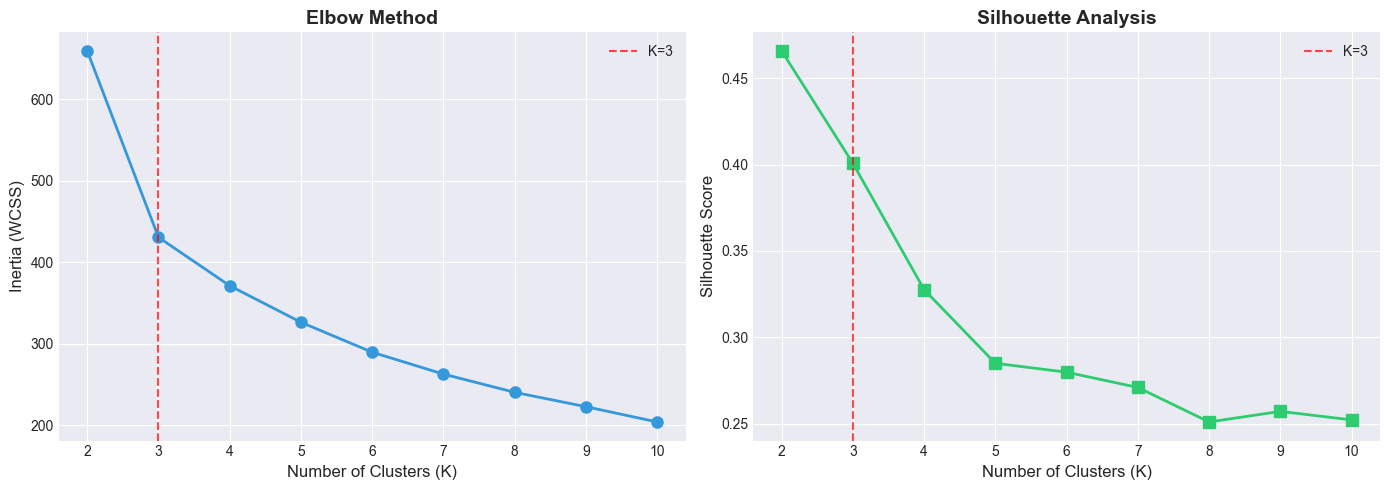

Best K by Silhouette Score: 2


In [3]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, inertias, 'o-', color='#3498db', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='K=3')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].legend()

# Silhouette score plot
axes[1].plot(k_range, silhouette_scores, 's-', color='#2ecc71', linewidth=2, markersize=8)
axes[1].axvline(x=3, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='K=3')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Best K by Silhouette Score: {k_range[np.argmax(silhouette_scores)]}")

### 4. K-Means with K=3

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means Clustering (K=3)")
print("=" * 45)
print(f"Inertia: {kmeans.inertia_:.4f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}")
print(f"Number of iterations: {kmeans.n_iter_}")
print(f"\nCluster sizes: {np.bincount(kmeans_labels)}")

K-Means Clustering (K=3)
Inertia: 430.6590
Silhouette Score: 0.4007
Number of iterations: 7

Cluster sizes: [72 67 71]


In [5]:
# Compare with true labels
ari = adjusted_rand_score(y_true, kmeans_labels)
nmi = normalized_mutual_info_score(y_true, kmeans_labels)
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Normalized Mutual Info: {nmi:.4f}")

Adjusted Rand Index: 0.7733
Normalized Mutual Info: 0.7279


### 5. Visualize K-Means Clusters (PCA)

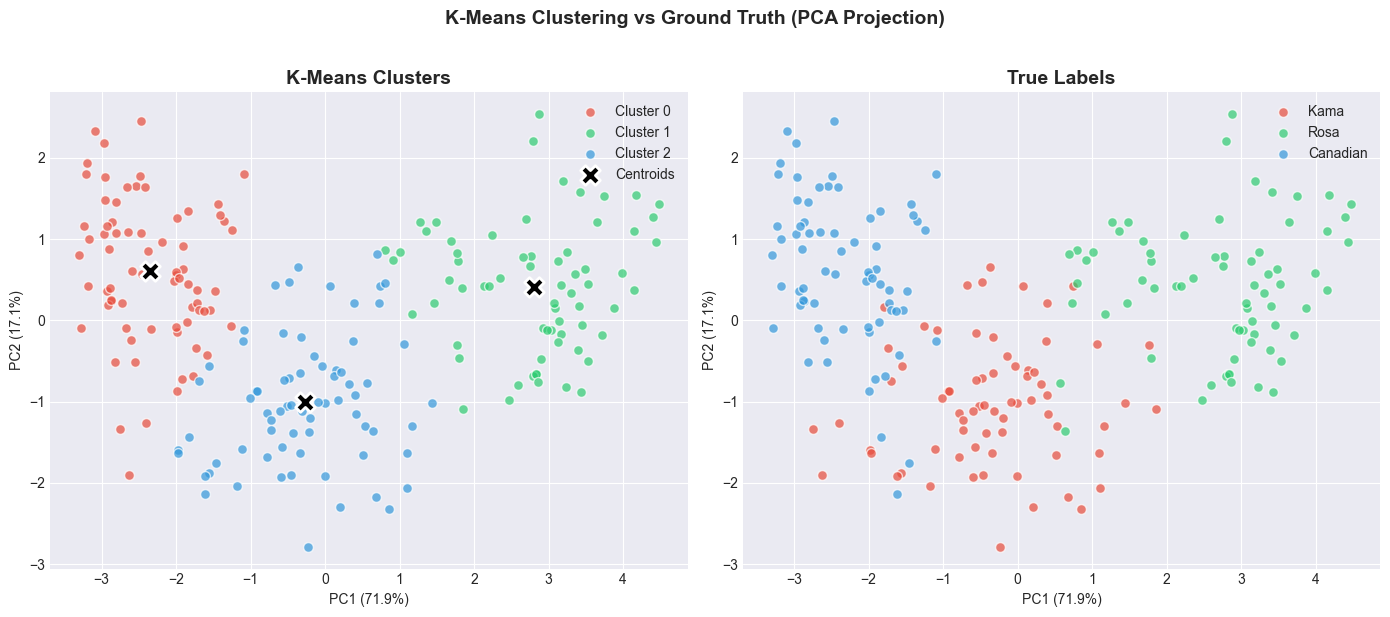

In [6]:
# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#e74c3c', '#2ecc71', '#3498db']

# K-Means clusters
for i in range(3):
    mask = kmeans_labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i],
                    label=f'Cluster {i}', alpha=0.7, s=50, edgecolors='white')

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black',
                marker='X', s=200, edgecolors='white', linewidth=2, label='Centroids')
axes[0].set_title('K-Means Clusters', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# True labels
class_names = ['Kama', 'Rosa', 'Canadian']
for i, cls in enumerate(sorted(y_true.unique())):
    mask = y_true == cls
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i],
                    label=class_names[i], alpha=0.7, s=50, edgecolors='white')

axes[1].set_title('True Labels', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend()

plt.suptitle('K-Means Clustering vs Ground Truth (PCA Projection)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6. Silhouette Plot

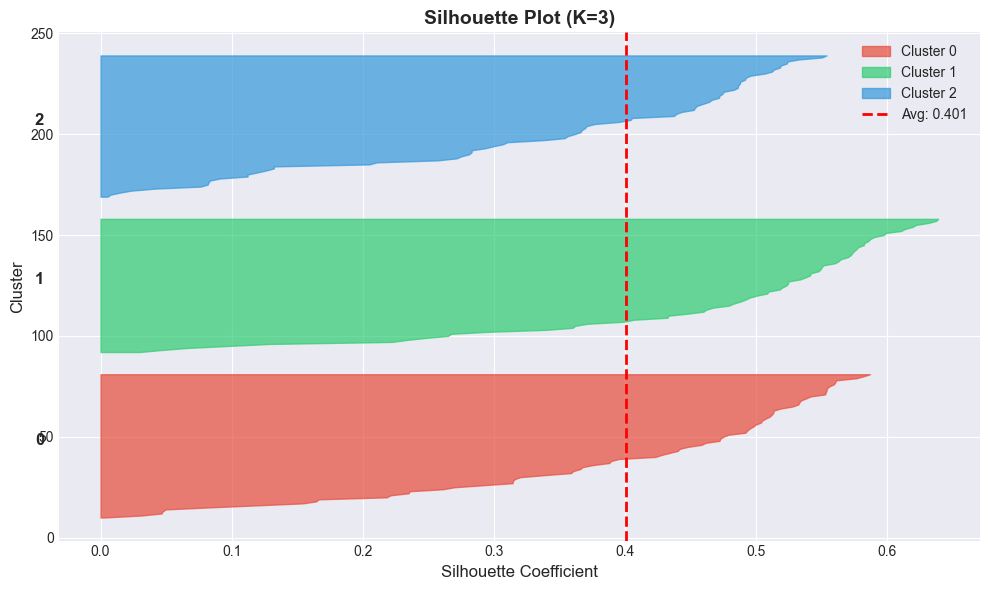

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

sample_silhouette_values = silhouette_samples(X_scaled, kmeans_labels)
y_lower = 10

for i in range(3):
    cluster_silhouette_values = sample_silhouette_values[kmeans_labels == i]
    cluster_silhouette_values.sort()
    size = cluster_silhouette_values.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_values,
                      alpha=0.7, color=colors[i], label=f'Cluster {i}')
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=12, fontweight='bold')
    y_lower = y_upper + 10

avg_score = silhouette_score(X_scaled, kmeans_labels)
ax.axvline(x=avg_score, color='red', linestyle='--', linewidth=2, label=f'Avg: {avg_score:.3f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title('Silhouette Plot (K=3)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 7. Cluster Centroids Analysis

In [8]:
# Inverse transform centroids to original scale
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids_original, columns=feature_cols, index=['Cluster 0', 'Cluster 1', 'Cluster 2'])

print("Cluster Centroids (Original Scale):")
centroids_df.round(4)

Cluster Centroids (Original Scale):


,Area,Perimeter,Compactness,Length_of_kernel,Width_of_kernel,Asymmetry_coefficient,Length_of_kernel_groove
Cluster 0,11.8569,13.2478,0.8483,5.2318,2.8495,4.7424,5.1017
Cluster 1,18.4954,16.2034,0.8842,6.1757,3.6975,3.6324,6.0417
Cluster 2,14.4379,14.3377,0.8816,5.5146,3.2592,2.7073,5.1208


---
## Part B: Hierarchical Clustering

### 8. Dendrogram

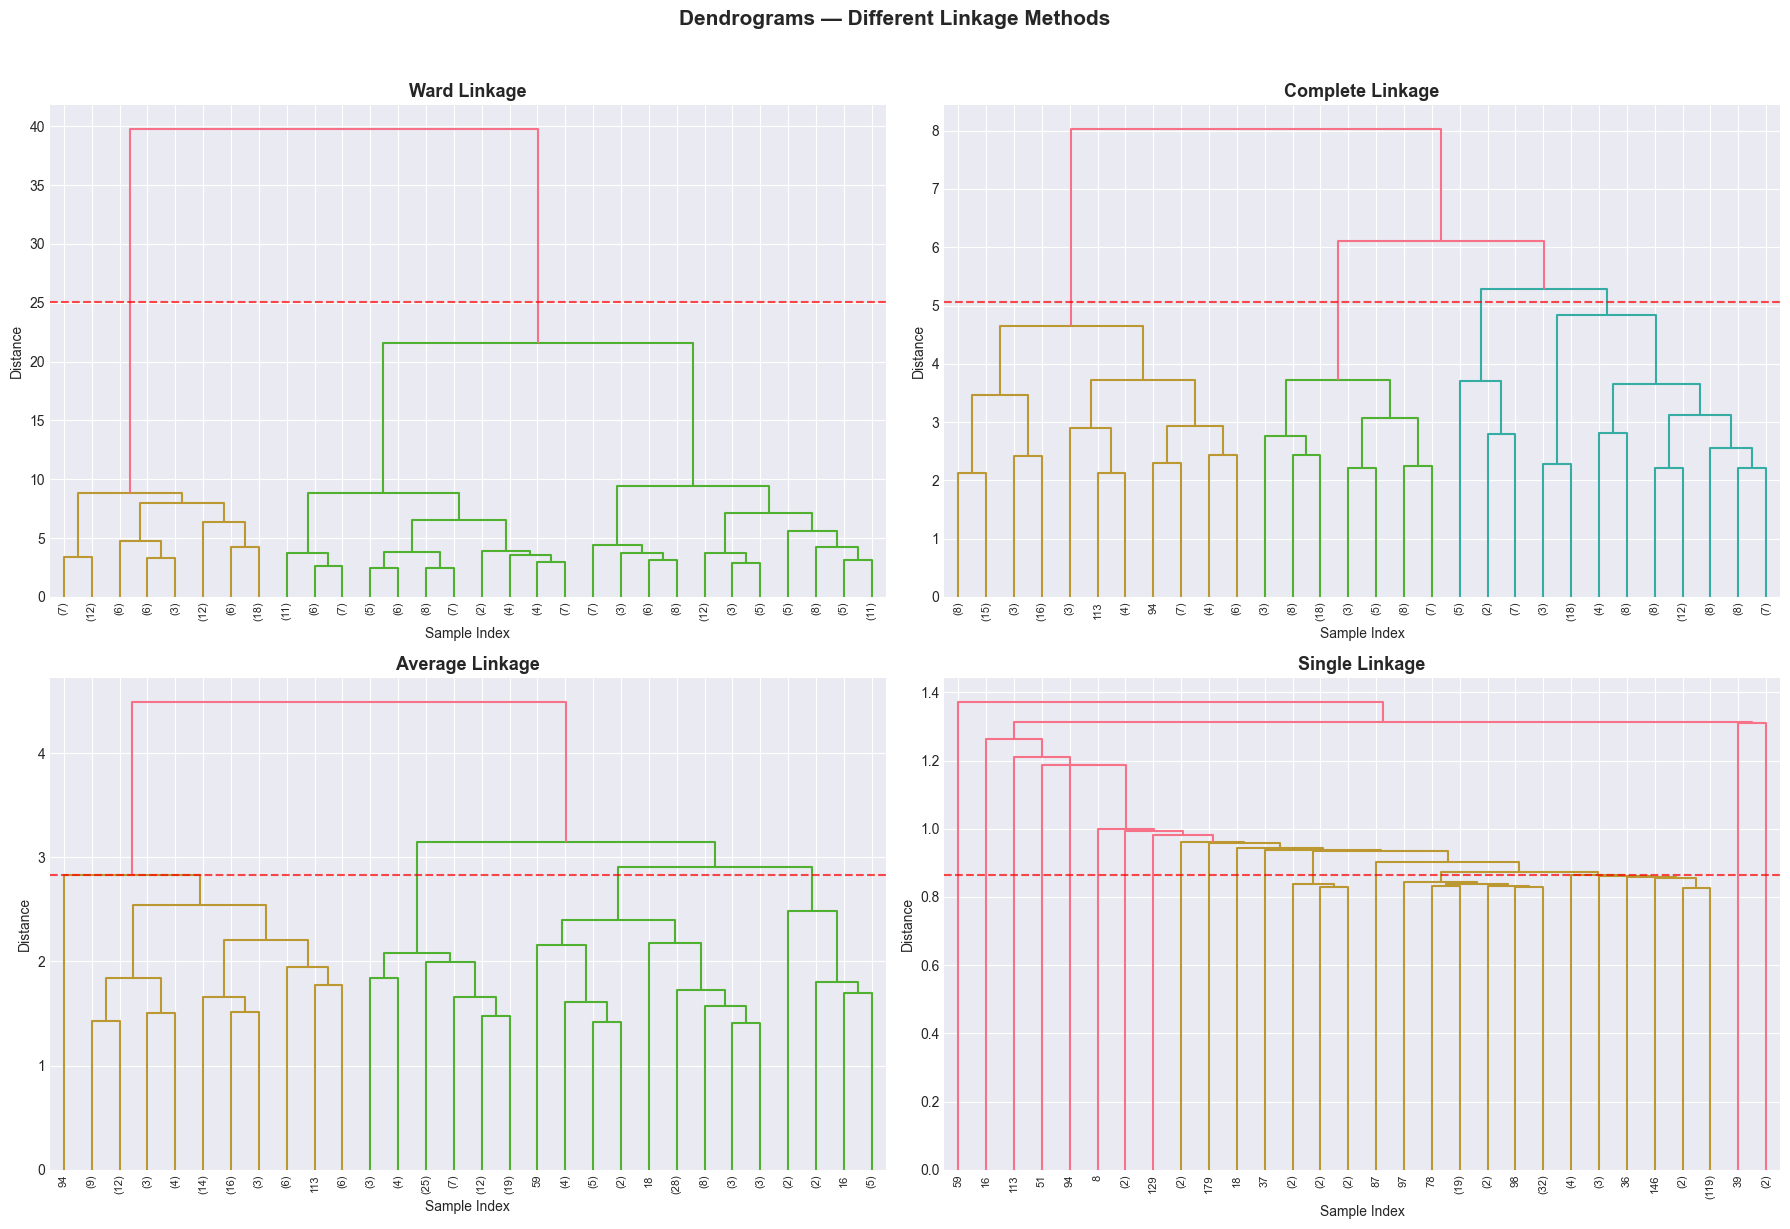

In [9]:
# Compute linkage matrix
linkage_methods = ['ward', 'complete', 'average', 'single']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, method in enumerate(linkage_methods):
    Z = linkage(X_scaled, method=method)
    dendrogram(Z, truncate_mode='lastp', p=30, ax=axes[i],
               leaf_rotation=90, leaf_font_size=8)
    axes[i].set_title(f'{method.capitalize()} Linkage', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Distance')
    axes[i].axhline(y=axes[i].get_ylim()[1]*0.6, color='red', linestyle='--',
                     linewidth=1.5, alpha=0.7)

plt.suptitle('Dendrograms — Different Linkage Methods', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9. Full Dendrogram (Ward Linkage)

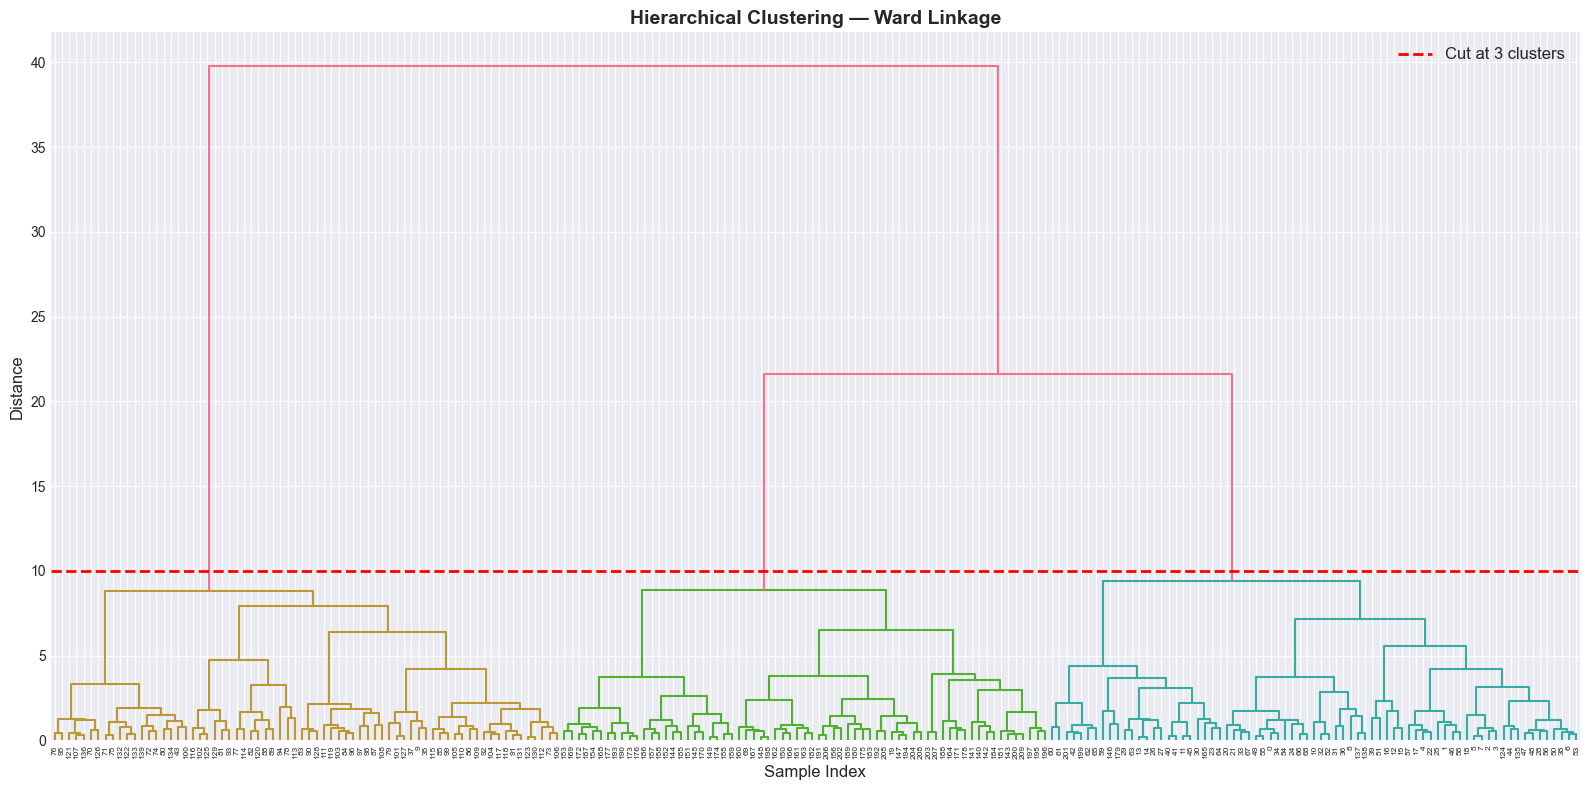

In [10]:
fig, ax = plt.subplots(figsize=(16, 8))

Z_ward = linkage(X_scaled, method='ward')
dendrogram(Z_ward, ax=ax, leaf_rotation=90, leaf_font_size=6, color_threshold=10)
ax.axhline(y=10, color='red', linestyle='--', linewidth=2, label='Cut at 3 clusters')
ax.set_title('Hierarchical Clustering — Ward Linkage', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Distance', fontsize=12)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 10. Agglomerative Clustering

In [11]:
# Test different linkage methods
hierarchical_results = []

for method in ['ward', 'complete', 'average', 'single']:
    agg = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = agg.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    hierarchical_results.append({
        'Linkage': method,
        'Silhouette Score': sil,
        'Adjusted Rand Index': ari,
        'NMI': nmi
    })

hc_comparison = pd.DataFrame(hierarchical_results)
print("Hierarchical Clustering — Linkage Comparison:")
hc_comparison

Hierarchical Clustering — Linkage Comparison:


,Linkage,Silhouette Score,Adjusted Rand Index,NMI
0,ward,0.392634,0.796998,0.749816
1,complete,0.350198,0.686263,0.701011
2,average,0.375957,0.685940,0.649192
3,single,-0.005642,0.000004,0.019815


In [12]:
# Best hierarchical model
best_linkage = hc_comparison.loc[hc_comparison['Silhouette Score'].idxmax(), 'Linkage']
print(f"Best linkage: {best_linkage}")

hc_model = AgglomerativeClustering(n_clusters=3, linkage=best_linkage)
hc_labels = hc_model.fit_predict(X_scaled)

print(f"Cluster sizes: {np.bincount(hc_labels)}")
print(f"Silhouette Score: {silhouette_score(X_scaled, hc_labels):.4f}")
print(f"Adjusted Rand Index: {adjusted_rand_score(y_true, hc_labels):.4f}")

Best linkage: ward
Cluster sizes: [73 70 67]
Silhouette Score: 0.3926
Adjusted Rand Index: 0.7970


### 11. Visualize Hierarchical Clusters

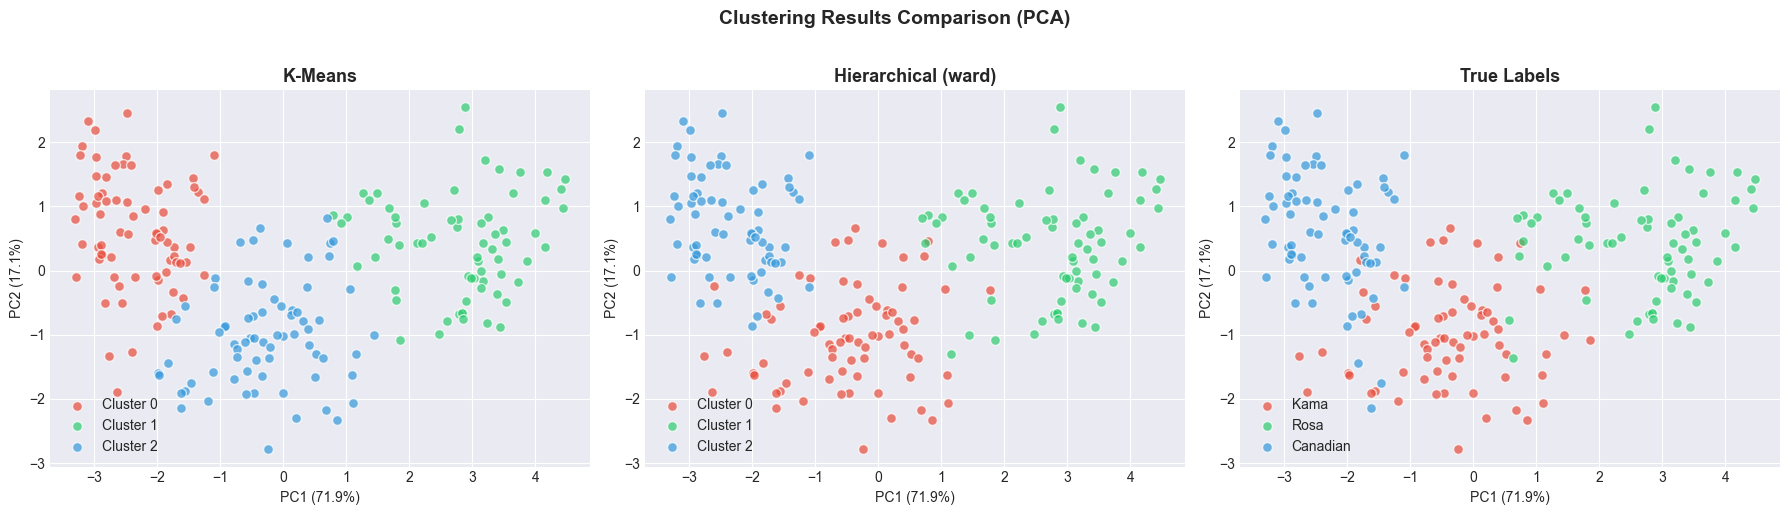

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
for i in range(3):
    mask = kmeans_labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i],
                    label=f'Cluster {i}', alpha=0.7, s=50, edgecolors='white')
axes[0].set_title('K-Means', fontsize=13, fontweight='bold')
axes[0].legend()

# Hierarchical
for i in range(3):
    mask = hc_labels == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i],
                    label=f'Cluster {i}', alpha=0.7, s=50, edgecolors='white')
axes[1].set_title(f'Hierarchical ({best_linkage})', fontsize=13, fontweight='bold')
axes[1].legend()

# True labels
for i, cls in enumerate(sorted(y_true.unique())):
    mask = y_true == cls
    axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i],
                    label=class_names[i], alpha=0.7, s=50, edgecolors='white')
axes[2].set_title('True Labels', fontsize=13, fontweight='bold')
axes[2].legend()

for ax in axes:
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

plt.suptitle('Clustering Results Comparison (PCA)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Final Comparison

In [14]:
final_comparison = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Adjusted Rand Index', 'NMI'],
    'K-Means': [
        silhouette_score(X_scaled, kmeans_labels),
        adjusted_rand_score(y_true, kmeans_labels),
        normalized_mutual_info_score(y_true, kmeans_labels)
    ],
    f'Hierarchical ({best_linkage})': [
        silhouette_score(X_scaled, hc_labels),
        adjusted_rand_score(y_true, hc_labels),
        normalized_mutual_info_score(y_true, hc_labels)
    ]
})

print("Final Comparison:")
final_comparison

Final Comparison:


,Metric,K-Means,Hierarchical (ward)
0,Silhouette Score,0.400727,0.392634
1,Adjusted Rand Index,0.773294,0.796998
2,NMI,0.727864,0.749816


## 13. Conclusion
In this lab, we:
- **K-Means**: Used the Elbow Method and Silhouette analysis to find optimal K=3. Visualized clusters with PCA.
- **Hierarchical Clustering**: Compared ward, complete, average, and single linkage. Visualized dendrograms.
- Both methods successfully identified the 3 wheat varieties in the unlabeled data.
- ARI and NMI scores measure agreement with true labels, confirming clustering effectiveness.